# makeshift — T1/T2/NOE from BMRB

Using makeshift to access other types of datasets and process relaxation datasets.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import makeshift as ms
from makeshift.relaxation import RelaxationProfile


## 1. Fetch a BMRB entry

`NMRStarEntry.from_bmrb` downloads the NMR-STAR file and parses it into all the datasets within the entry.

In [2]:
entry = ms.NMRStarEntry.from_bmrb(25013)
entry.datasets()

,entry,Type,Count
0,entry_information,heteronucl_NOEs,1
1,entry_information,heteronucl_T1_relaxation,1
2,entry_information,heteronucl_T2_relaxation,1


Key columns: `entry` (which sequence is this associated with), `Type` (what kind of dataset), `Count` (how many deposited)

## 2. Get the relaxation data (R1/R2/NOE)



In [3]:
entry.relaxation("T1")

,list,Seq_ID,Comp_ID,Atom_ID,Atom_type,Val,Val_err
0,heteronuclear_T1_list_1,3,GLU,N,N,1.095940,0.023623
1,heteronuclear_T1_list_1,4,ILE,N,N,1.074008,0.019584
2,heteronuclear_T1_list_1,5,GLY,N,N,1.150232,0.012199
3,heteronuclear_T1_list_1,6,ILE,N,N,1.131409,0.017149
4,heteronuclear_T1_list_1,7,PHE,N,N,1.108346,0.017810
...,...,...,...,...,...,...,...
107,heteronuclear_T1_list_1,145,GLY,N,N,1.091210,0.018142
108,heteronuclear_T1_list_1,146,THR,N,N,1.129880,0.024968
109,heteronuclear_T1_list_1,147,LEU,N,N,1.168894,0.018942
110,heteronuclear_T1_list_1,148,LEU,N,N,1.098458,0.015815


In [4]:
entry.relaxation("NOE")

,list,Seq_ID,Comp_ID,Atom_ID,Seq_ID_2,Comp_ID_2,Atom_ID_2,Val,Val_err
0,heteronuclear_noe_list_1,3,GLU,N,3,GLU,H,0.828892,0.009283
1,heteronuclear_noe_list_1,4,ILE,N,4,ILE,H,0.896477,0.000406
2,heteronuclear_noe_list_1,5,GLY,N,5,GLY,H,0.851774,0.008999
3,heteronuclear_noe_list_1,6,ILE,N,6,ILE,H,0.850187,0.001047
4,heteronuclear_noe_list_1,7,PHE,N,7,PHE,H,0.845435,0.047174
...,...,...,...,...,...,...,...,...,...
107,heteronuclear_noe_list_1,145,GLY,N,145,GLY,H,0.845448,0.009607
108,heteronuclear_noe_list_1,146,THR,N,146,THR,H,0.830828,0.003064
109,heteronuclear_noe_list_1,147,LEU,N,147,LEU,H,0.839238,0.003524
110,heteronuclear_noe_list_1,148,LEU,N,148,LEU,H,0.834077,0.002509


## 3. Get other order parameters

`Rex` and its respective model-free fitting can be found in the order parameter depositions

In [5]:
entry2 = ms.NMRStarEntry.from_bmrb(17041)
entry2.order_parameters()

,list,Seq_ID,Comp_ID,Atom_ID,S2,S2_err,Tau_e,Rex,Model_fit
0,order_parameter_list_1,12,TYR,N,0.22,0.03,808.0,NaN,5
1,order_parameter_list_1,14,ALA,N,0.45,0.00,878.0,NaN,5
2,order_parameter_list_1,16,MET,N,0.46,0.02,1100.0,NaN,5
3,order_parameter_list_1,17,ALA,N,0.61,0.02,931.0,NaN,5
4,order_parameter_list_1,19,GLN,N,0.68,0.03,1320.0,NaN,2
...,...,...,...,...,...,...,...,...,...
67,order_parameter_list_1,108,VAL,N,0.89,0.02,16.3,NaN,2
68,order_parameter_list_1,109,LEU,N,0.91,0.03,NaN,NaN,1
69,order_parameter_list_1,110,LEU,N,0.91,0.02,112.0,NaN,2
70,order_parameter_list_1,111,LYS,N,0.39,0.02,1150.0,NaN,5


## 4. Plot the relaxation profile for BMRB Entry 

This method extracts T1/T2/NOE data from the BMRB and processes it with HydroNMR following the RelaxDB processing (see Wayment-Steele and El Nesr et. al.). To calculate rigid-body tumbling, input a PDB reference or use a model associated with the BMRB entry.

  no pdb given; using afdb structure P65367
structure_pro_: read 1147 atoms, 1147 beads (AER=3.0 Angs) from /home/users/gelnesr/.makeshift/structures/AF-P65367-F1-v6.pdb
ROTATIONAL DIFFUSION TENSOR
[[19794229.9241216    810544.94740941 -1741313.00032567]
 [  810544.94740945 19756191.88797073   264559.90317561]
 [-1741313.00032569   264559.90317558 22321919.99910133]]
Rotational diffusion coefficient: 2.062e+07 s-1
Rotational diffusion anisotropy: 4.215e+06 s-1
Relaxation time (1): 8.672e-09 s
Relaxation time (2): 8.545e-09 s
Relaxation time (3): 8.151e-09 s
Relaxation time (4): 7.604e-09 s
Relaxation time (5): 7.566e-09 s
Harm. mean relax.(correlation) time: 8.081e-09 s
Angular resonance frequency of 1H: 3.140e+09 rad.s^-1
Angular resonance frequency of X: 3.185e+08 rad.s^-1
  HYDRONMR: 112 residues matched structure to data, scale factor 2.046 (110 ordered residues used)

MAEIGIFVGTMYGNSLLVAEEAEAILTAQGHKATVFEDPELSDWLPYQDKYVLVVTSTTGQGDLPDSIVPLFQGIKDSLGFQPNLRYGVIALGDSSYVNFCNGGKQFDALLQEQ

<Axes: xlabel='Residue'>

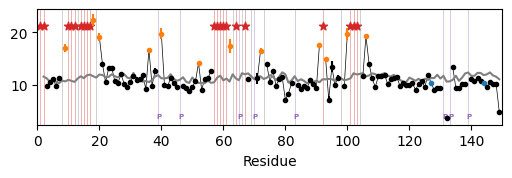

In [6]:
from makeshift import PeakList
from makeshift.relaxation import RelaxationProfile

# 1) Identify peaklist 
pl = PeakList.from_bmrb(19151)
#    prof = Peaklist.from_csv(my_csv.csv) # provide a dataframe from csv

# 2) Build T1/T2/NOE from BMRB. Provide peaklist for residues assigned.
prof = RelaxationProfile.from_bmrb(25013, peaklist=pl)
#    prof =  RelaxationProfile.from_bmrb(25013, peaklist=[5,6,7]) # list assigned residues

# 3) Add the rigid-body reference
prof.add_rigid_prediction(source="afdb")
#    or force the source:
#    prof.add_rigid_prediction("1WRP")       # a specific deposited PDB
#    prof.add_rigid_prediction("A1AJW2")     # the AlphaFold model (UniProt acc)
#    prof.add_rigid_prediction("my_model.pdb")

# 4) Label each residue and plot the R2/R1 profile.
labels = prof.label(rex_n_std=1.0, noe_cut=0.65)

print('\n' + prof.sequence)
print(labels)               # e.g. AAAA^AA..vAb…p   (A ordered, ^ rex, v ps-ns, b both)
prof.plot("R2_R1")          # or prof.plot("NOE")